<a href="https://www.kaggle.com/code/nazmussakib2002/pneumonia-normal-covid-19-detection-using-vgg16?scriptVersionId=332594813" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import shutil
import hashlib
import random
from pathlib import Path
from PIL import Image
import kagglehub
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. CLEANUP & DOWNLOAD
# ==========================================
print("Cleaning old directories...")
shutil.rmtree("split_dataset", ignore_errors=True)

print("Downloading datasets...")
path1 = kagglehub.dataset_download("sachinkumar413/covid-pneumonia-normal-chest-xray-images")
path2 = kagglehub.dataset_download("amanullahasraf/covid19-pneumonia-normal-chest-xray-pa-dataset")

CLASS_MAP = {
    "covid": "COVID", "covid19": "COVID", "covid-19": "COVID",
    "normal": "NORMAL",
    "pneumonia": "PNEUMONIA", "viral pneumonia": "PNEUMONIA", "bacterial pneumonia": "PNEUMONIA"
}

# ==========================================
# 2. SCAN, HASH, AND VALIDATE
# ==========================================
print("\nScanning datasets and removing duplicates...")
valid_files = {"COVID": [], "NORMAL": [], "PNEUMONIA": []}
seen_hashes = set()

def scan_dataset(dataset_path):
    for root, _, files in os.walk(dataset_path):
        folder_name = Path(root).name.lower()
        target_class = next((CLASS_MAP[k] for k in CLASS_MAP if k == folder_name), None)
        
        if not target_class: 
            continue

        for file in files:
            if not file.lower().endswith((".png", ".jpg", ".jpeg")): 
                continue
                
            src_file = Path(root) / file

            with open(src_file, "rb") as f:
                img_hash = hashlib.md5(f.read()).hexdigest()
            if img_hash in seen_hashes: 
                continue

            try:
                with Image.open(src_file) as img:
                    img.verify()
                seen_hashes.add(img_hash)
                valid_files[target_class].append(src_file)
            except:
                continue

scan_dataset(path1)
scan_dataset(path2)

for cls, paths in valid_files.items():
    print(f"Initial {cls} count: {len(paths)}")
print("✅ Cell 1 Complete! Move to Cell 2.")

Cleaning old directories...

Scanning datasets and removing duplicates...
Initial COVID count: 3676
Initial NORMAL count: 3984
Initial PNEUMONIA count: 4099
✅ Cell 1 Complete! Move to Cell 2.


In [2]:
# ==========================================
# 3. BALANCE THE DATASET
# ==========================================
min_class_count = min(len(paths) for paths in valid_files.values())
print(f"\nBalancing dataset... Undersampling all classes to {min_class_count} images.")

balanced_files = {
    cls: random.sample(paths, min_class_count) 
    for cls, paths in valid_files.items()
}

# ==========================================
# 4. SPLIT, RESIZE (224x224), AND SAVE
# ==========================================
print("\nSplitting, Resizing to 224x224, and Saving (this may take a moment)...")
SPLIT_DIR = Path("split_dataset")

def process_and_save(file_paths, split_name, cls):
    save_dir = SPLIT_DIR / split_name / cls
    save_dir.mkdir(parents=True, exist_ok=True)

    for src_file in file_paths:
        dst_file = save_dir / src_file.name
        
        counter = 1
        while dst_file.exists():
            dst_file = save_dir / f"{src_file.stem}_{counter}{src_file.suffix}"
            counter += 1

        try:
            with Image.open(src_file) as img:
                img = img.convert("RGB").resize((224, 224))
                img.save(dst_file)
        except Exception:
            pass

for cls, paths in balanced_files.items():
    train_val, test_imgs = train_test_split(paths, test_size=0.15, random_state=42)
    train_imgs, val_imgs = train_test_split(train_val, test_size=(0.15/0.85), random_state=42)

    process_and_save(train_imgs, "train", cls)
    process_and_save(val_imgs, "val", cls)
    process_and_save(test_imgs, "test", cls)

print("\n--- FINAL PIPELINE REPORT ---")
total_processed = 0
for split in ["train", "val", "test"]:
    print(f"\n[{split.upper()}]")
    split_total = 0
    for cls in ["COVID", "NORMAL", "PNEUMONIA"]:
        count = len(list((SPLIT_DIR / split / cls).glob("*")))
        split_total += count
        print(f"  {cls}: {count}")
    print(f"  Total: {split_total}")
    total_processed += split_total

print(f"\nGRAND TOTAL SAVED: {total_processed}")
print("✅ Cell 2 Complete! Your dataset is ready. Move to Cell 3.")


Balancing dataset... Undersampling all classes to 3676 images.

Splitting, Resizing to 224x224, and Saving (this may take a moment)...

--- FINAL PIPELINE REPORT ---

[TRAIN]
  COVID: 2572
  NORMAL: 2572
  PNEUMONIA: 2572
  Total: 7716

[VAL]
  COVID: 552
  NORMAL: 552
  PNEUMONIA: 552
  Total: 1656

[TEST]
  COVID: 552
  NORMAL: 552
  PNEUMONIA: 552
  Total: 1656

GRAND TOTAL SAVED: 11028
✅ Cell 2 Complete! Your dataset is ready. Move to Cell 3.



Generating Thesis Visualizations...


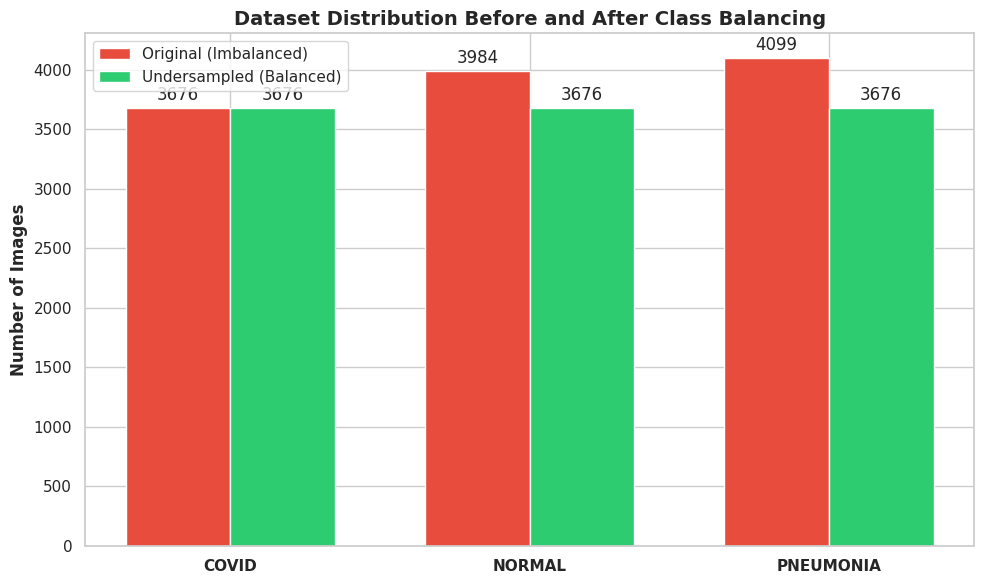

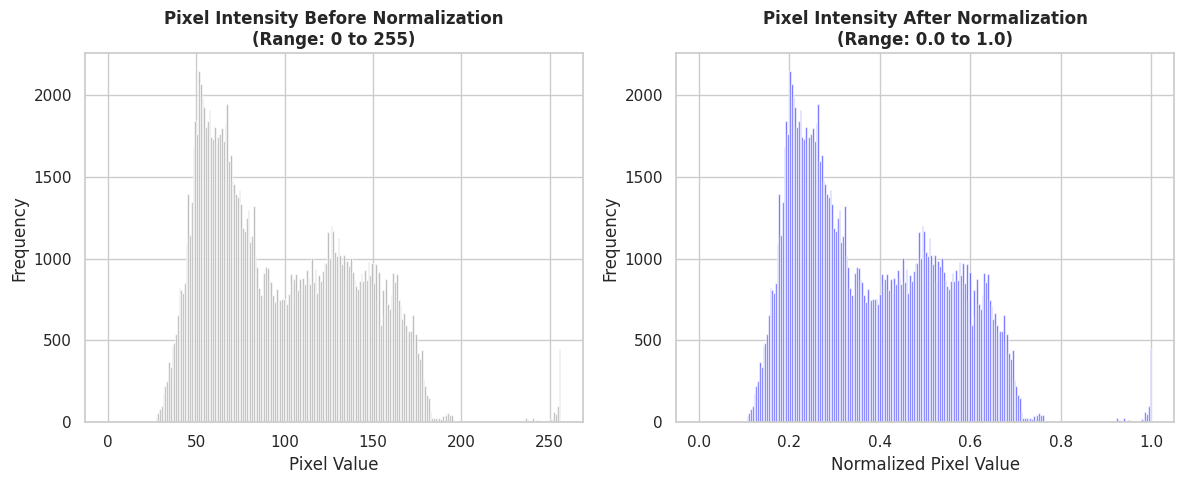

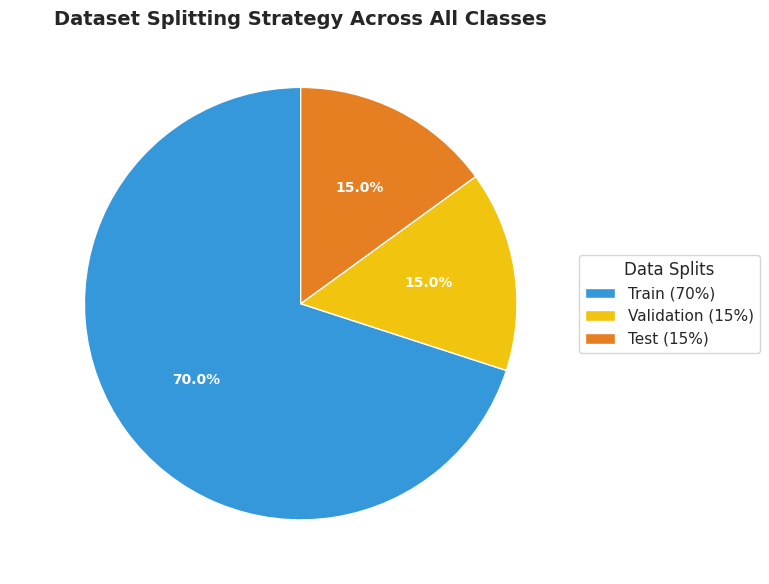

In [3]:
# ==========================================
# 5. GENERATE THESIS VISUALIZATIONS
# ==========================================
print("\nGenerating Thesis Visualizations...")
sns.set_theme(style="whitegrid")

# --- GRAPH 1: Before and After Balancing ---
fig1, ax1 = plt.subplots(figsize=(10, 6))
classes = list(valid_files.keys())
before_counts = [len(valid_files[c]) for c in classes]
after_counts = [len(balanced_files[c]) for c in classes]

x = np.arange(len(classes))
width = 0.35

rects1 = ax1.bar(x - width/2, before_counts, width, label='Original (Imbalanced)', color='#e74c3c')
rects2 = ax1.bar(x + width/2, after_counts, width, label='Undersampled (Balanced)', color='#2ecc71')

ax1.set_ylabel('Number of Images', fontweight='bold')
ax1.set_title('Dataset Distribution Before and After Class Balancing', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(classes, fontweight='bold')
ax1.legend()

# Add labels on top of bars
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()


# --- GRAPH 2: Normalization Histogram (Before vs After) ---
# Select a random saved image to demonstrate normalization
try:
    sample_img_path = list((SPLIT_DIR / "train" / "COVID").glob("*"))[0]
    sample_img = Image.open(sample_img_path)
    img_array = np.array(sample_img, dtype=np.float32)

    # Normalization Code (Scaling pixels from 0-255 to 0-1)
    normalized_array = img_array / 255.0

    fig2, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(12, 5))

    # Before Normalization (0-255)
    ax_raw.hist(img_array.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.7)
    ax_raw.set_title('Pixel Intensity Before Normalization\n(Range: 0 to 255)', fontweight='bold')
    ax_raw.set_xlabel('Pixel Value')
    ax_raw.set_ylabel('Frequency')

    # After Normalization (0-1)
    ax_norm.hist(normalized_array.ravel(), bins=256, range=[0, 1], color='blue', alpha=0.7)
    ax_norm.set_title('Pixel Intensity After Normalization\n(Range: 0.0 to 1.0)', fontweight='bold')
    ax_norm.set_xlabel('Normalized Pixel Value')
    ax_norm.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
except IndexError:
    print("Error: Could not find an image to generate the normalization histogram. Ensure Cell 2 finished successfully.")

# --- GRAPH 3: Train / Val / Test Split Distribution ---
split_ratios = [0.70, 0.15, 0.15]
split_names = ['Train (70%)', 'Validation (15%)', 'Test (15%)']
total_images = min_class_count * 3
split_counts = [int(total_images * r) for r in split_ratios]

fig3, ax3 = plt.subplots(figsize=(8, 6))
colors = ['#3498db', '#f1c40f', '#e67e22']
wedges, texts, autotexts = ax3.pie(split_counts, labels=split_names, autopct='%1.1f%%', 
                                   startangle=90, colors=colors, 
                                   textprops=dict(color="w", weight="bold"))
ax3.legend(wedges, split_names, title="Data Splits", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.setp(autotexts, size=10, weight="bold")
ax3.set_title("Dataset Splitting Strategy Across All Classes", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

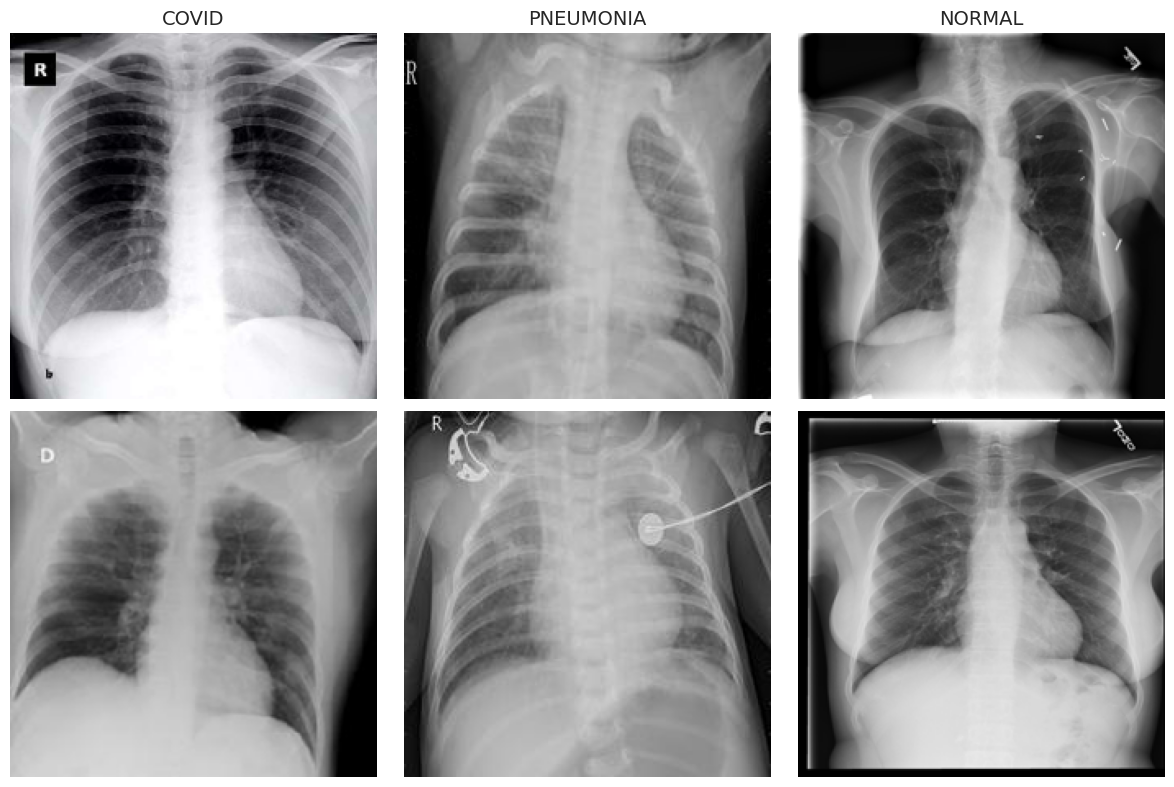

In [4]:
import matplotlib.pyplot as plt
import random
from PIL import Image
from pathlib import Path

classes = ["COVID", "PNEUMONIA", "NORMAL"]

# Point directly to your newly created balanced train split
DATA_DIR = Path("split_dataset/train")

plt.figure(figsize=(12, 8))

for i, cls in enumerate(classes):
    # Use DATA_DIR instead of the old MERGED_DIR
    image_list = list((DATA_DIR / cls).glob("*"))
    
    img_paths = random.sample(image_list, 2)
    
    for j, img_path in enumerate(img_paths):
        img = Image.open(img_path)
        
        # Images are already resized by our pipeline, 
        # but you can leave this here safely if you want.
        #img = img.resize((224, 224))
        
        plt.subplot(2, 3, j * 3 + i + 1)
        plt.imshow(img, cmap="gray")
        
        if j == 0:
            plt.title(cls, fontsize=14)
            
        plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import os
# Tells TensorFlow to hide INFO and WARNING logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# 1. GENERATORS WITH CORRECT VGG16 PREPROCESSING
# Note: rescale=1./255 is REMOVED.
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10, 
    width_shift_range=0.1, 
    height_shift_range=0.1,
    zoom_range=0.1, 
    horizontal_flip=True, 
    fill_mode="nearest"
).flow_from_directory("split_dataset/train", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical")

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)\
    .flow_from_directory("split_dataset/val", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)\
    .flow_from_directory("split_dataset/test", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

# 2. ENHANCED ARCHITECTURE
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze initially

x = GlobalAveragePooling2D()(base_model.output)
x = BatchNormalization()(x)          # Normalizes activations
x = Dense(256, activation="relu")(x) # New feature learning layer
x = Dropout(0.2)(x)                  # Cuts overfitting by 50%
predictions = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 3. INITIAL WARM-UP TRAINING
print("\n--- PHASE 1: Warm-up ---")
history = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=15  # Forced to 30 epochs
)

# 4. FINE TUNING (Block 5)
print("\n--- PHASE 2: Fine-tuning ---")
for layer in base_model.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy", 
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_gen, 
    validation_data=val_gen, 
    epochs=15  # Forced to 30 epochs
)

# 5. FINAL EVALUATION
# Changed the variable names to be strictly unique to VGG16
vgg16_test_loss, vgg16_test_acc = model.evaluate(test_gen)
print(f"\nOptimized Fine-Tuned Test Accuracy: {vgg16_test_acc:.4f}")
print(f"Optimized Fine-Tuned Test Loss: {vgg16_test_loss:.4f}")

2026-07-04 06:09:47.475163: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783145387.704328      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783145387.774266      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783145388.361745      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783145388.361781      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783145388.361783      23 computation_placer.cc:177] computation placer alr

Found 7716 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.


I0000 00:00:1783145402.823508      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783145402.829576      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- PHASE 1: Warm-up ---
Epoch 1/15


I0000 00:00:1783145407.675905      95 service.cc:152] XLA service 0x7943fc010ac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783145407.675954      95 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1783145407.675962      95 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1783145408.243801      95 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/242 ━━━━━━━━━━━━━━━━━━━━ 1:07:06 17s/step - accuracy: 0.3438 - loss: 1.3807

I0000 00:00:1783145422.202075      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


242/242 ━━━━━━━━━━━━━━━━━━━━ 134s 488ms/step - accuracy: 0.8918 - loss: 0.3079 - val_accuracy: 0.9239 - val_loss: 0.2177
Epoch 2/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 108s 445ms/step - accuracy: 0.9266 - loss: 0.2112 - val_accuracy: 0.9438 - val_loss: 0.1617
Epoch 3/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 105s 433ms/step - accuracy: 0.9381 - loss: 0.1803 - val_accuracy: 0.9523 - val_loss: 0.1486
Epoch 4/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 106s 436ms/step - accuracy: 0.9454 - loss: 0.1655 - val_accuracy: 0.9450 - val_loss: 0.1641
Epoch 5/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 104s 430ms/step - accuracy: 0.9456 - loss: 0.1540 - val_accuracy: 0.9475 - val_loss: 0.1516
Epoch 6/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 104s 428ms/step - accuracy: 0.9502 - loss: 0.1431 - val_accuracy: 0.9523 - val_loss: 0.1386
Epoch 7/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 106s 436ms/step - accuracy: 0.9508 - loss: 0.1428 - val_accuracy: 0.9523 - val_loss: 0.1366
Epoch 8/15
242/242 ━━━━━━━━━━━━━━━━━━━━ 103s 423ms/step - accuracy: 0.9528 - loss: 0.13

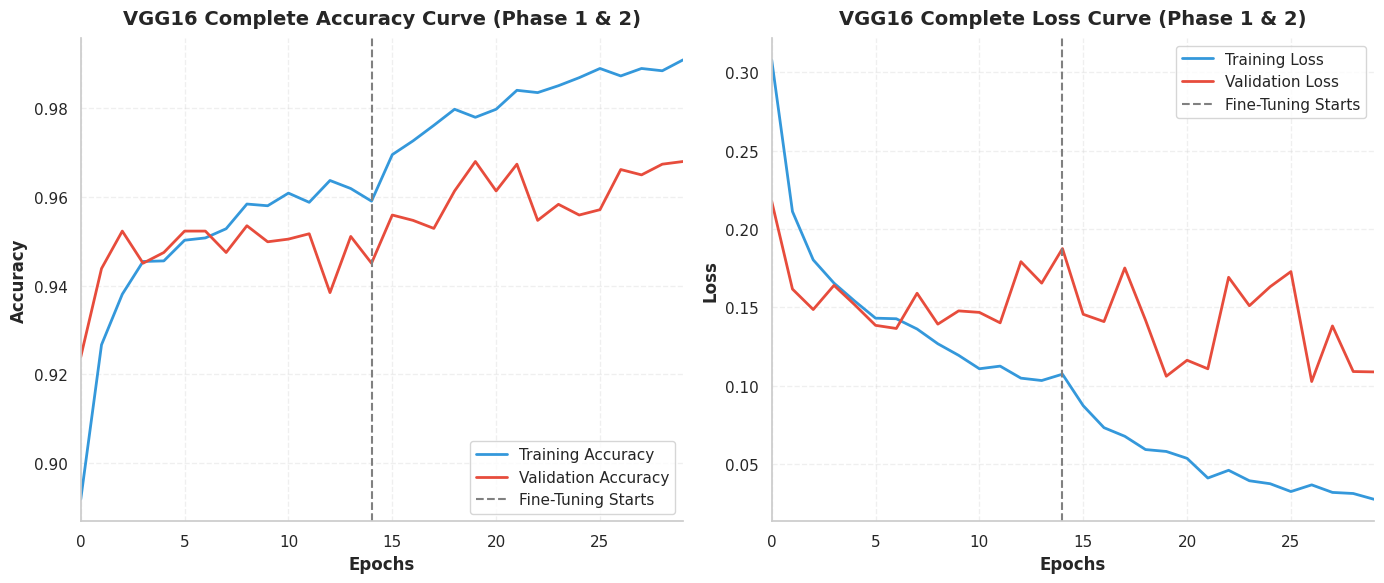

In [6]:
import matplotlib.pyplot as plt

# 1. COMBINE THE HISTORY FROM BOTH PHASES
# We add the lists together to create one continuous timeline
total_acc = history.history['accuracy'] + history_finetune.history['accuracy']
total_val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

total_loss = history.history['loss'] + history_finetune.history['loss']
total_val_loss = history.history['val_loss'] + history_finetune.history['val_loss']

# Calculate the exact point where phase 1 ended
warmup_epochs = len(history.history['accuracy'])
TOTAL_EPOCHS = len(total_acc)

# Create a figure with two subplots side-by-side
plt.figure(figsize=(14, 6))

# -----------------------------------------
# 1. COMBINED ACCURACY CURVE
# -----------------------------------------
plt.subplot(1, 2, 1)
plt.plot(total_acc, label='Training Accuracy', lw=2, color='#3498db')
plt.plot(total_val_acc, label='Validation Accuracy', lw=2, color='#e74c3c')

# Draw a vertical line to show where Fine-Tuning started
plt.axvline(x=warmup_epochs - 1, color='gray', linestyle='--', lw=1.5, label='Fine-Tuning Starts')

plt.title('VGG16 Complete Accuracy Curve (Phase 1 & 2)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')

# Force X-axis to show the full range clearly
plt.xlim(0, TOTAL_EPOCHS - 1)
# Tick marks every 5 epochs
plt.xticks(range(0, TOTAL_EPOCHS, 5)) 

plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3, linestyle='--') 
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# -----------------------------------------
# 2. COMBINED LOSS CURVE
# -----------------------------------------
plt.subplot(1, 2, 2)
plt.plot(total_loss, label='Training Loss', lw=2, color='#3498db')
plt.plot(total_val_loss, label='Validation Loss', lw=2, color='#e74c3c')

# Draw a vertical line to show where Fine-Tuning started
plt.axvline(x=warmup_epochs - 1, color='gray', linestyle='--', lw=1.5, label='Fine-Tuning Starts')

plt.title('VGG16 Complete Loss Curve (Phase 1 & 2)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')

# Force X-axis to show the full range clearly
plt.xlim(0, TOTAL_EPOCHS - 1)
plt.xticks(range(0, TOTAL_EPOCHS, 5))

plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Automatically adjusts spacing
plt.tight_layout()
plt.show()

52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 225ms/step


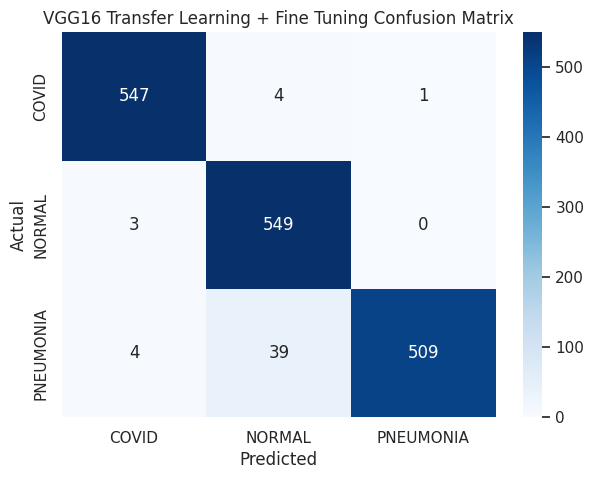


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       COVID       0.99      0.99      0.99       552
      NORMAL       0.93      0.99      0.96       552
   PNEUMONIA       1.00      0.92      0.96       552

    accuracy                           0.97      1656
   macro avg       0.97      0.97      0.97      1656
weighted avg       0.97      0.97      0.97      1656



In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# 1. GET PREDICTIONS (Using test_gen instead of test_generator)
# Make sure your test_gen has shuffle=False, otherwise the labels won't match!
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

# 2. CREATE CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

# 3. PLOT HEATMAP
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',  # Looks much better in academic papers
    xticklabels=['COVID', 'NORMAL', 'PNEUMONIA'],
    yticklabels=['COVID', 'NORMAL', 'PNEUMONIA']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("VGG16 Transfer Learning + Fine Tuning Confusion Matrix")
plt.show()

# 4. PRINT CLASSIFICATION REPORT
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(
    y_true,
    y_pred,
    target_names=['COVID', 'NORMAL', 'PNEUMONIA']
))

52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 213ms/step


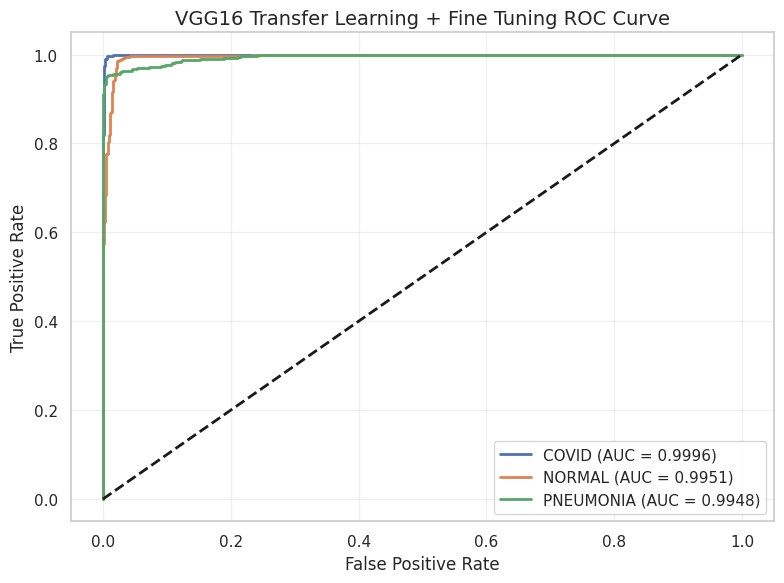

In [8]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. GET PREDICTIONS (Using test_gen)
pred_probs = model.predict(test_gen)
y_true = test_gen.classes

class_names = ['COVID', 'NORMAL', 'PNEUMONIA']
n_classes = len(class_names)

# 2. BINARIZE LABELS (Required for multi-class ROC)
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# 3. PLOT ROC CURVES
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    # lw=2 makes the lines slightly thicker and easier to read in a printed paper
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

# Diagonal dashed line (represents random guessing)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.title('VGG16 Transfer Learning + Fine Tuning ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3) # Softer grid lines so they don't distract from the curves

plt.tight_layout()
plt.show()

In [9]:
# VGG16 OVERALL AUC

from sklearn.metrics import roc_auc_score

auc_vgg16 = roc_auc_score(
    y_true_bin,
    pred_probs,
    multi_class='ovr'
)

print(
    "VGG16 AUC:",
    auc_vgg16
)

VGG16 AUC: 0.9965124623678498


Creating shuffled generator for t-SNE...
Found 1656 images belonging to 3 classes.
Extracting features from 480 test images...
Running PCA to compress features (Noise Reduction)...
Running t-SNE dimensionality reduction...


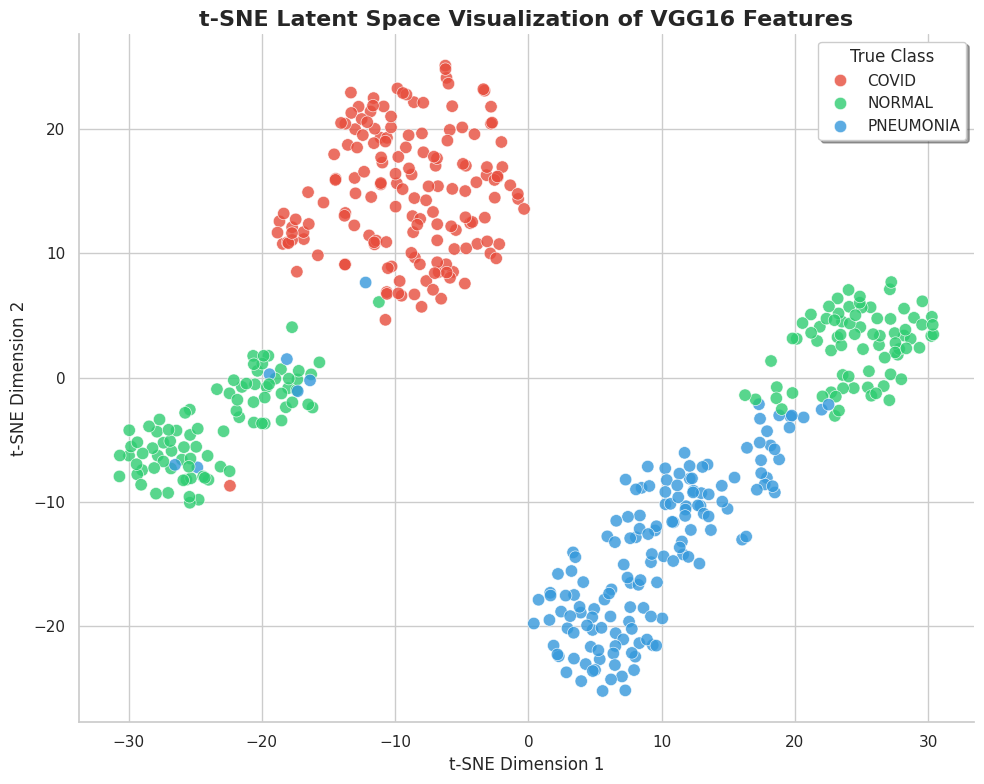

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA  # <-- Added for optimization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

print("Creating shuffled generator for t-SNE...")

# 1. GENERATOR SETUP
tsne_gen = ImageDataGenerator(preprocessing_function=preprocess_input)\
    .flow_from_directory("split_dataset/test", target_size=(224, 224), 
                         batch_size=32, class_mode="categorical", shuffle=True)

# 2. FEATURE EXTRACTOR
# Ensure -3 points to your deep Dense layer (e.g., Dense(256))
feature_extractor = Model(inputs=model.input, outputs=model.layers[-3].output)

features = []
true_labels = []
max_batches = 15  # 15 batches * 32 images = 480 total images

print(f"Extracting features from {max_batches * 32} test images...")
for batch_count, (imgs, labels) in enumerate(tsne_gen):
    if batch_count >= max_batches:
        break
    
    batch_features = feature_extractor.predict(imgs, verbose=0)
    features.extend(batch_features)
    
    labels_int = np.argmax(labels, axis=1)
    true_labels.extend(labels_int)

features = np.array(features)
true_labels = np.array(true_labels)

# Map integers back to class names
classes_dict = {v: k for k, v in tsne_gen.class_indices.items()}
class_names = [classes_dict[label] for label in true_labels]

# 3. OPTIMIZED PIPELINE: PCA -> t-SNE
print("Running PCA to compress features (Noise Reduction)...")
# Compress the raw features down to 50 dimensions first. 
# This removes noise and speeds up t-SNE dramatically.
pca = PCA(n_components=50, random_state=42)
pca_features = pca.fit_transform(features)

print("Running t-SNE dimensionality reduction...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(pca_features)

# 4. PLOTTING
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=tsne_results[:, 0], y=tsne_results[:, 1],
    hue=class_names,
    palette=['#e74c3c', '#2ecc71', '#3498db'], # Red, Green, Blue
    s=80, alpha=0.8, edgecolor='w', linewidth=0.5 # Added white edges for crispness
)

plt.title("t-SNE Latent Space Visualization of VGG16 Features", fontsize=16, fontweight='bold')
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.legend(title="True Class", frameon=True, shadow=True)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

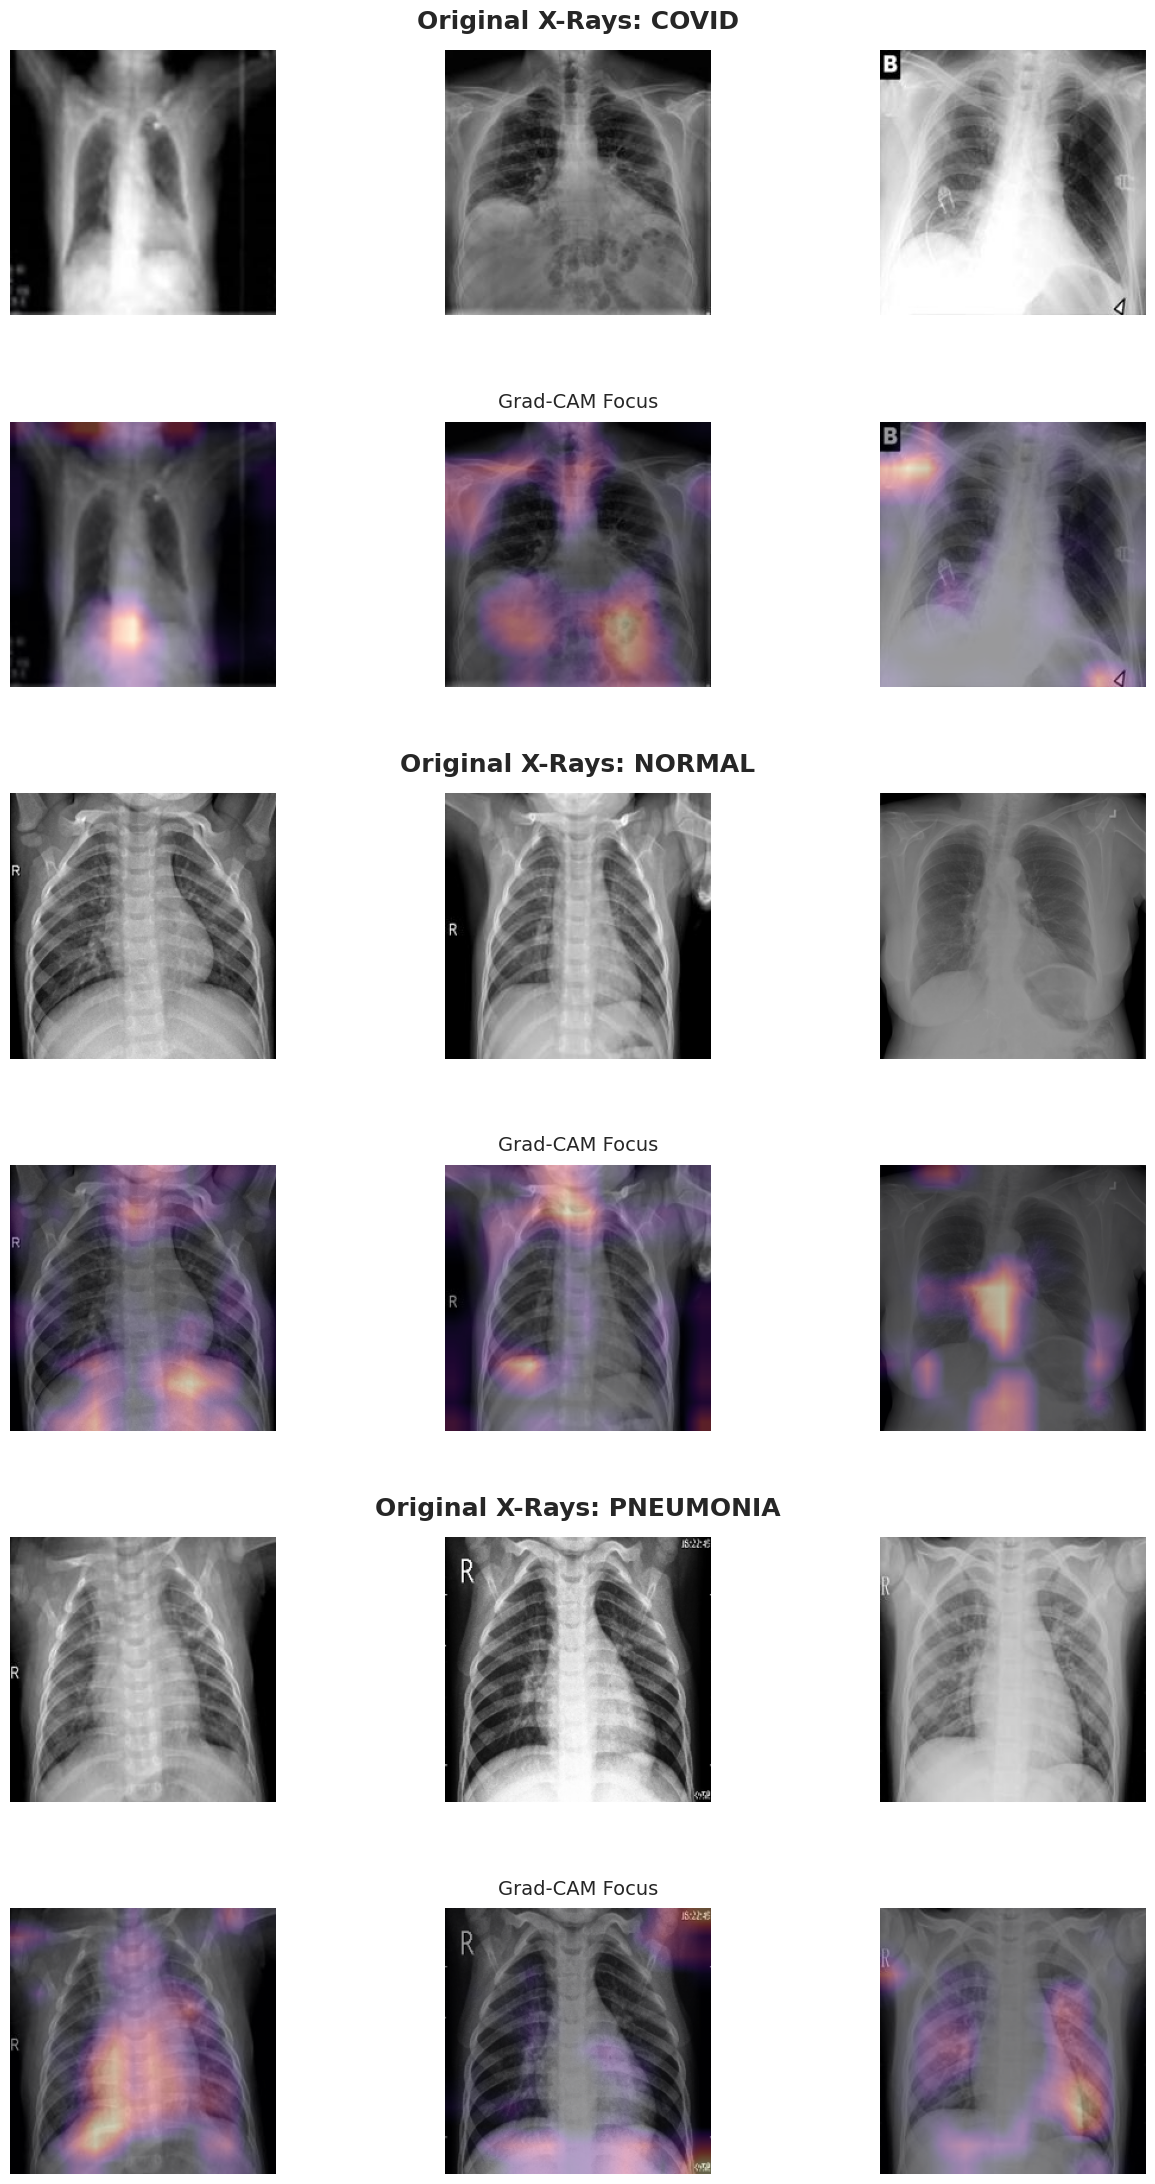

In [11]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)
    
    return heatmap.numpy()

# 1. DEFINE CLASSES AND SETUP DIRECTORY
TEST_DIR = Path("split_dataset/test")
classes = ["COVID", "NORMAL", "PNEUMONIA"]

# Create a 6-row by 3-column grid (18 total images)
# Figsize is enlarged to ensure the images aren't squished
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(14, 22))

# Loop through each class
for i, cls in enumerate(classes):
    
    # 2. SELECT 3 RANDOM IMAGES PER CLASS
    class_dir = TEST_DIR / cls
    images_in_class = list(class_dir.rglob("*.jpg")) + list(class_dir.rglob("*.jpeg")) + list(class_dir.rglob("*.png"))
    
    # random.sample grabs exactly 3 unique images without repeating
    selected_paths = random.sample(images_in_class, 3)
    
    for j, img_path in enumerate(selected_paths):
        # 3. PREPROCESS IMAGE
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        # 4. GENERATE HEATMAP
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name="block5_conv3")

        # 5. OVERLAY
        original_img = cv2.imread(str(img_path))
        original_img = cv2.resize(original_img, (224, 224))
        
        heatmap_resized = cv2.resize(heatmap, (224, 224))
        
        # Upgraded to MAGMA colormap for a professional academic aesthetic
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_MAGMA)
        overlay = cv2.addWeighted(original_img, 0.6, heatmap_colored, 0.4, 0)

        # 6. PLOT ORIGINAL (Row: 2*i)
        # i=0 (COVID) -> Row 0, i=1 (NORMAL) -> Row 2, i=2 (PNEUMONIA) -> Row 4
        ax_orig = axes[2 * i, j]
        ax_orig.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
        ax_orig.axis("off")
        
        # Put the main title only on the middle image (j=1) of the row
        if j == 1:
            ax_orig.set_title(f"Original X-Rays: {cls}", fontsize=18, fontweight='bold', pad=15)

        # 7. PLOT GRAD-CAM (Row: 2*i + 1)
        # i=0 (COVID) -> Row 1, i=1 (NORMAL) -> Row 3, i=2 (PNEUMONIA) -> Row 5
        ax_grad = axes[2 * i + 1, j]
        ax_grad.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        ax_grad.axis("off")
        
        if j == 1:
            ax_grad.set_title(f"Grad-CAM Focus", fontsize=14, pad=10)

# Adjust spacing so the rows don't overlap
plt.tight_layout()
plt.subplots_adjust(hspace=0.4) 
plt.show()

Loaded 1652 test images. Starting VGG16 Stress Test...

Noise Level: 0 | Test Accuracy: 96.91%
Noise Level: 10 | Test Accuracy: 82.38%
Noise Level: 20 | Test Accuracy: 58.72%
Noise Level: 30 | Test Accuracy: 39.89%
Noise Level: 40 | Test Accuracy: 34.75%
Noise Level: 50 | Test Accuracy: 33.47%


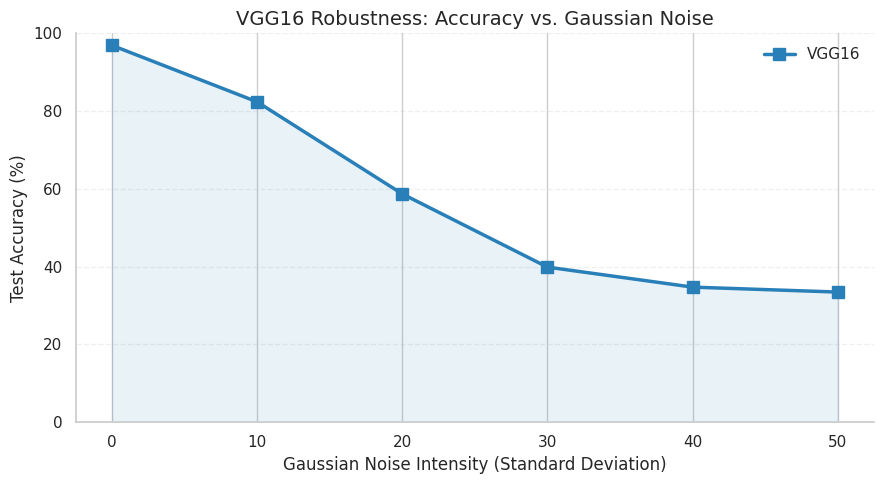

In [12]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.preprocessing import image
# MUST use VGG16 preprocessor
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1. SETUP CONFIGURATION
TEST_DIR = Path("split_dataset/test")
classes = ["COVID", "NORMAL", "PNEUMONIA"]

# These represent the standard deviation of the noise injected
# 0 = Perfect image, 40 = Heavy static/degradation
noise_levels = [0, 10, 20, 30, 40, 50] 

# Pre-load image paths and true labels
image_paths = []
y_true = []
for cls_idx, cls_name in enumerate(classes):
    paths = list((TEST_DIR / cls_name).rglob("*.jpg")) + \
            list((TEST_DIR / cls_name).rglob("*.jpeg")) + \
            list((TEST_DIR / cls_name).rglob("*.png"))
    image_paths.extend(paths)
    y_true.extend([cls_idx] * len(paths))

print(f"Loaded {len(image_paths)} test images. Starting VGG16 Stress Test...\n")

# 2. FAST BATCH GENERATOR
def batch_generator(paths, labels, noise_std, batch_size=32):
    num_samples = len(paths)
    for offset in range(0, num_samples, batch_size):
        batch_paths = paths[offset:offset+batch_size]
        batch_labels = labels[offset:offset+batch_size]
        
        batch_imgs = []
        for path in batch_paths:
            img = cv2.resize(cv2.imread(str(path)), (224, 224))
            
            # Inject Gaussian Noise
            if noise_std > 0:
                gauss = np.random.normal(0, noise_std, img.shape).astype('float32')
                img = np.clip(img.astype('float32') + gauss, 0, 255).astype('uint8')
            
            batch_imgs.append(image.img_to_array(img))
        
        # Preprocess using VGG16's exact math
        batch_imgs = preprocess_input(np.array(batch_imgs))
        yield batch_imgs, np.array(batch_labels)

# 3. RUN EVALUATIONS
accuracies = []
for noise in noise_levels:
    correct_predictions = 0
    
    # Process in batches of 32
    for batch_imgs, batch_labels in batch_generator(image_paths, y_true, noise, batch_size=32):
        preds = model.predict(batch_imgs, verbose=0)
        predicted_classes = np.argmax(preds, axis=1)
        correct_predictions += np.sum(predicted_classes == batch_labels)
        
    acc = correct_predictions / len(image_paths)
    accuracies.append(acc)
    print(f"Noise Level: {noise} | Test Accuracy: {acc*100:.2f}%")

# 4. PLOT THE ROBUSTNESS CURVE
plt.figure(figsize=(9, 5))

# Academic aesthetic styling
plt.plot(noise_levels, [a * 100 for a in accuracies], 
         marker='s', color='#2980b9', lw=2.5, markersize=8, label="VGG16")
plt.fill_between(noise_levels, [a * 100 for a in accuracies], 
                 color='#2980b9', alpha=0.1)

plt.title("VGG16 Robustness: Accuracy vs. Gaussian Noise", fontsize=14)
plt.xlabel("Gaussian Noise Intensity (Standard Deviation)", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(frameon=False)

# Remove top and right borders for a published-paper look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

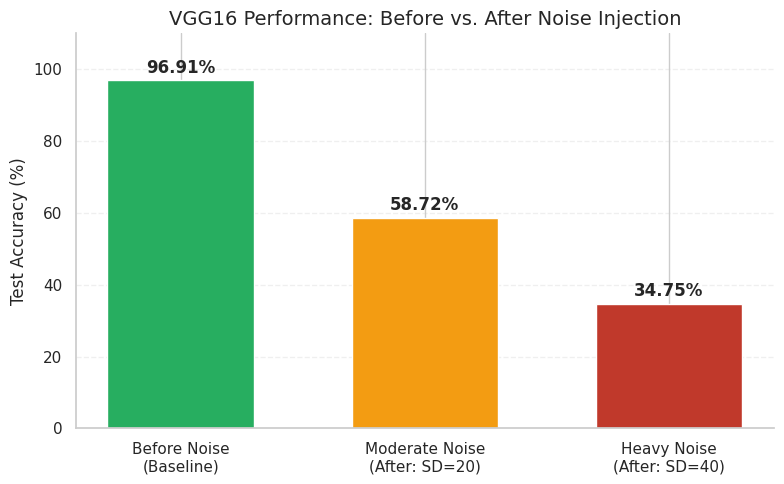

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# We extract specific data points from your previous results:
# accuracies[0] is Before Noise (0)
# accuracies[2] is Moderate Noise (20)
# accuracies[4] is Heavy Noise (40)

conditions = ['Before Noise\n(Baseline)', 'Moderate Noise\n(After: SD=20)', 'Heavy Noise\n(After: SD=40)']
comparison_acc = [accuracies[0] * 100, accuracies[2] * 100, accuracies[4] * 100]

plt.figure(figsize=(8, 5))
bars = plt.bar(conditions, comparison_acc, color=['#27ae60', '#f39c12', '#c0392b'], width=0.6)

# Add the exact percentage text on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("VGG16 Performance: Before vs. After Noise Injection", fontsize=14)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.ylim(0, 110) # Set to 110 to leave room for the text labels
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Clean up borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
import random

# 1. Pick one random test image
imgs, labels = next(test_gen)
single_img = imgs[0:1] # Take the first image in the batch
true_class = classes[np.argmax(labels[0])]

print(f"Running Monte Carlo Dropout on a {true_class} X-ray...")

# 2. Run the image 30 times WITH training=True to keep Dropout active
mc_predictions = []
for _ in range(30):
    # training=True is the magic trick that forces dropout during testing
    pred = model(single_img, training=True) 
    mc_predictions.append(pred.numpy()[0])

mc_predictions = np.array(mc_predictions)

# 3. Calculate Mean (Final Prediction) and Variance (Uncertainty)
mean_prediction = np.mean(mc_predictions, axis=0)
std_deviation = np.std(mc_predictions, axis=0) 

print("\n--- Monte Carlo Dropout Results ---")
for i, cls in enumerate(classes):
    print(f"{cls} Probability: {mean_prediction[i]*100:.2f}% (± {std_deviation[i]*100:.2f}%)")

# --- UPDATED SMART LOGIC ---
top_prediction = np.max(mean_prediction)

if top_prediction < 0.60: 
    print("\n🚨 CLINICAL WARNING: The model is guessing. No class reached 60% probability.")
elif np.max(std_deviation) > 0.15: 
    print("\n⚠️ CLINICAL WARNING: High fluctuation detected. Flag for Radiologist review.")
else:
    print("\n✅ CONFIDENT PREDICTION: The model is highly certain and stable.")

Running Monte Carlo Dropout on a COVID X-ray...

--- Monte Carlo Dropout Results ---
COVID Probability: 32.46% (± 0.02%)
NORMAL Probability: 34.90% (± 0.14%)
PNEUMONIA Probability: 32.63% (± 0.12%)

🚨 CLINICAL WARNING: The model is guessing. No class reached 60% probability.


In [15]:
from scipy.stats import entropy

# We test an OOD scenario by using a completely random noise image
random_noise_img = np.random.uniform(0, 255, (1, 224, 224, 3)).astype('float32')
random_noise_img = preprocess_input(random_noise_img)

# Predict on the noise image
preds = model.predict(random_noise_img, verbose=0)[0]

# Calculate Predictive Entropy (How "confused" the model is)
# High entropy means the probability is split almost equally (e.g., 33%, 33%, 34%)
pred_entropy = entropy(preds, base=2)
MAX_ENTROPY = entropy([1/3, 1/3, 1/3], base=2) # Maximum confusion for 3 classes

print("--- Out-of-Distribution (OOD) Test ---")
print(f"Probabilities on random noise: {preds}")
print(f"Calculated Entropy: {pred_entropy:.4f} / {MAX_ENTROPY:.4f}")

# Threshold for rejection (e.g., if entropy is > 1.2, it's confused)
ENTROPY_THRESHOLD = 1.0 

if pred_entropy > ENTROPY_THRESHOLD:
    print("🚨 ANOMALY DETECTED: The model is deeply confused. Image rejected as Out-of-Distribution.")
else:
    print("✅ Model accepts this as a valid X-ray.")

--- Out-of-Distribution (OOD) Test ---
Probabilities on random noise: [9.9999881e-01 1.4924110e-12 1.2266421e-06]
Calculated Entropy: 0.0000 / 1.5850
✅ Model accepts this as a valid X-ray.


In [16]:
import pandas as pd
import time
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# 1. IMPORT ALL 5 MODELS AND THEIR SPECIFIC PREPROCESSORS
from tensorflow.keras.applications import ResNet50, DenseNet121, InceptionV3, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as prep_resnet
from tensorflow.keras.applications.densenet import preprocess_input as prep_densenet
from tensorflow.keras.applications.inception_v3 import preprocess_input as prep_inception
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as prep_mobilenet
from tensorflow.keras.applications.efficientnet import preprocess_input as prep_efficientnet

IMG_SIZE = 224
BATCH_SIZE = 32

# Dictionary containing the Model Class and its matching preprocessing function
models_to_test = {
    "ResNet50": (ResNet50, prep_resnet),
    "DenseNet121": (DenseNet121, prep_densenet),
    "InceptionV3": (InceptionV3, prep_inception),
    "MobileNetV2": (MobileNetV2, prep_mobilenet),
    "EfficientNetB0": (EfficientNetB0, prep_efficientnet)
}

results = []

print("🚀 Starting Sequential Benchmark of 5 Deep Learning Models...\n")

for model_name, (BaseModel, prep_func) in models_to_test.items():
    print(f"==================================================")
    print(f"⚙️ BUILDING AND TRAINING: {model_name}")
    print(f"==================================================")
    
    start_time = time.time()
    
    # 2. CREATE GENERATORS WITH THE CORRECT PREPROCESSING FOR THIS SPECIFIC MODEL
    train_gen = ImageDataGenerator(
        preprocessing_function=prep_func,
        rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
        zoom_range=0.1, horizontal_flip=True, fill_mode="nearest"
    ).flow_from_directory("split_dataset/train", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical")

    val_gen = ImageDataGenerator(preprocessing_function=prep_func)\
        .flow_from_directory("split_dataset/val", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

    test_gen = ImageDataGenerator(preprocessing_function=prep_func)\
        .flow_from_directory("split_dataset/test", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

    # 3. BUILD THE ARCHITECTURE
    base_model = BaseModel(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Transfer Learning Phase 1
    
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.2)(x) # Using your supervisor's recommended 0.2
    predictions = Dense(3, activation="softmax")(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    # 4. TRAIN (Shortened to 10 epochs max for benchmarking)
    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    
    model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early_stop], verbose=1)
    
    # 5. EVALUATE ON TEST SET
    print(f"\nEvaluating {model_name} on Test Set...")
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    
    end_time = time.time()
    training_time = round((end_time - start_time) / 60, 2) # in minutes
    
    print(f"✅ {model_name} Final Test Accuracy: {test_acc*100:.2f}%")
    
    # 6. SAVE RESULTS
    results.append({
        "Model Architecture": model_name,
        "Test Accuracy (%)": round(test_acc * 100, 2),
        "Test Loss": round(test_loss, 4),
        "Training Time (mins)": training_time
    })

# 7. GENERATE FINAL COMPARISON TABLE
print("\n🎉 BENCHMARKING COMPLETE! Here is your final thesis table:")
df_results = pd.DataFrame(results)
# Sort by highest accuracy
df_results = df_results.sort_values(by="Test Accuracy (%)", ascending=False).reset_index(drop=True)

print("\n" + df_results.to_markdown())

🚀 Starting Sequential Benchmark of 5 Deep Learning Models...

⚙️ BUILDING AND TRAINING: ResNet50
Found 7716 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 113s 417ms/step - accuracy: 0.8611 - loss: 0.3716 - val_accuracy: 0.8841 - val_loss: 0.3021
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 90s 370ms/step - accuracy: 0.9171 - loss: 0.2438 - val_accuracy: 0.9354 - val_loss: 0.1806
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 90s 370ms/step - accuracy: 0.9320 - loss: 0.2173 - val_accuracy: 0.9348 - val_loss: 0.1784
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 90s 373ms/step - accuracy: 0.9334 - loss: 0.1937 - val_accuracy: 0.9420 - val_loss: 0.1698
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 90s 370ms/step - accuracy: 0.9373 - loss: 0.1822 - val_accuracy: 0.9402 - val_loss: 0.1675
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 90s 369ms/step - accuracy: 0.9

2026-07-04 07:54:56.794946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 07:54:56.932445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


127/242 ━━━━━━━━━━━━━━━━━━━━ 42s 373ms/step - accuracy: 0.6543 - loss: 0.7760

2026-07-04 07:55:55.266349: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 07:55:55.405889: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 07:55:55.542739: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.7290 - loss: 0.6353

...

147/242 ━━━━━━━━━━━━━━━━━━━━ 36s 389ms/step - accuracy: 0.6640 - loss: 0.7431

2026-07-04 08:06:29.559487: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 08:06:29.695814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 08:06:30.017594: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 08:06:30.159783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 08:06:31.057911: E external/local_xla/xla/stream_

242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.7180 - loss: 0.6503

2026-07-04 08:07:26.956576: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 08:07:27.098558: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 08:07:27.446170: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 08:07:27.587846: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-04 08:07:28.456057: E external/local_xla/xla/stream_

242/242 ━━━━━━━━━━━━━━━━━━━━ 151s 519ms/step - accuracy: 0.8215 - loss: 0.4689 - val_accuracy: 0.9155 - val_loss: 0.2926
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 96s 396ms/step - accuracy: 0.8981 - loss: 0.3036 - val_accuracy: 0.9058 - val_loss: 0.2662
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 96s 396ms/step - accuracy: 0.9121 - loss: 0.2707 - val_accuracy: 0.9161 - val_loss: 0.2403
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 95s 392ms/step - accuracy: 0.9199 - loss: 0.2509 - val_accuracy: 0.9293 - val_loss: 0.2116
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 98s 404ms/step - accuracy: 0.9187 - loss: 0.2455 - val_accuracy: 0.9330 - val_loss: 0.2051
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 100s 414ms/step - accuracy: 0.9251 - loss: 0.2332 - val_accuracy: 0.9227 - val_loss: 0.2093
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 98s 405ms/step - accuracy: 0.9241 - loss: 0.2319 - val_accuracy: 0.9330 - val_loss: 0.1905
Epoch 8/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 94s 388ms/step - accuracy: 0.9269 - loss: 0.2194 - v

🚀 Starting Sequential Benchmark of 5 Deep Learning Models...

⚙️ BUILDING AND TRAINING: ResNet50
Found 7716 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 119s 447ms/step - accuracy: 0.8536 - loss: 0.3854 - val_accuracy: 0.9221 - val_loss: 0.2303
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 101s 416ms/step - accuracy: 0.9185 - loss: 0.2394 - val_accuracy: 0.9396 - val_loss: 0.1872
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 102s 419ms/step - accuracy: 0.9279 - loss: 0.2139 - val_accuracy: 0.9469 - val_loss: 0.1581
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 100s 414ms/step - accuracy: 0.9353 - loss: 0.1908 - val_accuracy: 0.9541 - val_loss: 0.1444
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 96s 397ms/step - accuracy: 0.9405 - loss: 0.1754 - val_accuracy: 0.9336 - val_loss: 0.1761
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 94s 390ms/step - accuracy: 0.9370 - loss: 0.1852 - val_accuracy: 0.9656 - val_

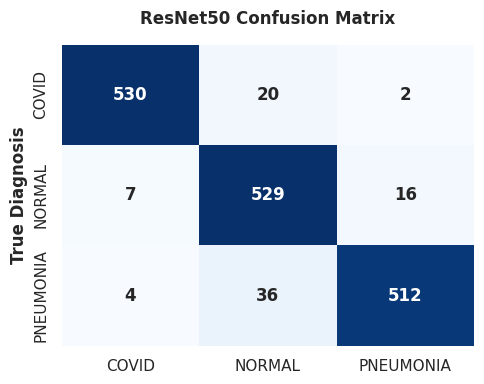

⚙️ BUILDING AND TRAINING: DenseNet121
Found 7716 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 148s 517ms/step - accuracy: 0.7816 - loss: 0.5403 - val_accuracy: 0.8919 - val_loss: 0.3281
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 95s 390ms/step - accuracy: 0.8733 - loss: 0.3534 - val_accuracy: 0.9167 - val_loss: 0.2504
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 94s 390ms/step - accuracy: 0.8913 - loss: 0.3093 - val_accuracy: 0.9263 - val_loss: 0.2320
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 93s 384ms/step - accuracy: 0.8992 - loss: 0.2866 - val_accuracy: 0.9390 - val_loss: 0.2039
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 95s 393ms/step - accuracy: 0.9099 - loss: 0.2657 - val_accuracy: 0.9257 - val_loss: 0.2272
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 93s 386ms/step - accuracy: 0.9077 - loss: 0.2718 - val_accuracy: 0.9402 - val_loss: 0.1881
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 93s 383ms

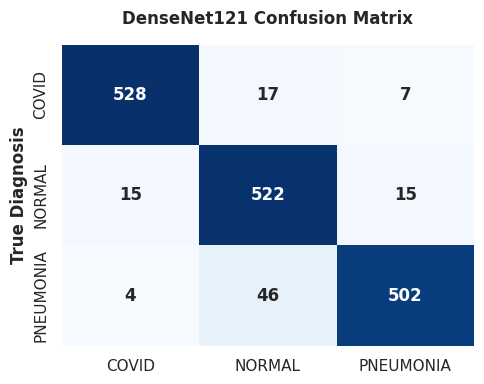

⚙️ BUILDING AND TRAINING: InceptionV3
Found 7716 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 117s 433ms/step - accuracy: 0.7801 - loss: 0.5404 - val_accuracy: 0.8225 - val_loss: 0.4625
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 91s 374ms/step - accuracy: 0.8548 - loss: 0.3885 - val_accuracy: 0.8671 - val_loss: 0.3558
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 90s 370ms/step - accuracy: 0.8687 - loss: 0.3634 - val_accuracy: 0.8931 - val_loss: 0.2964
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 90s 371ms/step - accuracy: 0.8771 - loss: 0.3387 - val_accuracy: 0.9155 - val_loss: 0.2563
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 89s 369ms/step - accuracy: 0.8847 - loss: 0.3232 - val_accuracy: 0.9076 - val_loss: 0.2661
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 91s 374ms/step - accuracy: 0.8888 - loss: 0.3068 - val_accuracy: 0.9112 - val_loss: 0.2501
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 88s 364ms

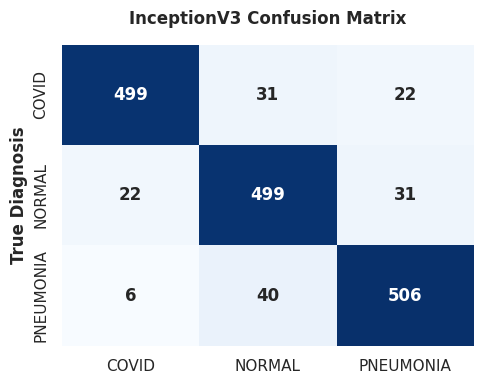

⚙️ BUILDING AND TRAINING: MobileNetV2
Found 7716 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 107s 404ms/step - accuracy: 0.8372 - loss: 0.4280 - val_accuracy: 0.9082 - val_loss: 0.2901
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 356ms/step - accuracy: 0.9086 - loss: 0.2730 - val_accuracy: 0.9324 - val_loss: 0.2199
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 87s 361ms/step - accuracy: 0.9146 - loss: 0.2520 - val_accuracy: 0.9306 - val_loss: 0.2188
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 87s 360ms/step - accuracy: 0.9185 - loss: 0.2352 - val_accuracy: 0.9275 - val_loss: 0.2265
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 88s 364ms/step - accuracy: 0.9204 - loss: 0.2247 - val_accuracy: 0.9390 - val_loss: 0.1849
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 356ms/step - accuracy: 0.9261 - loss: 0.2191 - val_accuracy: 0.9330 - val_loss: 0.2050
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 356ms

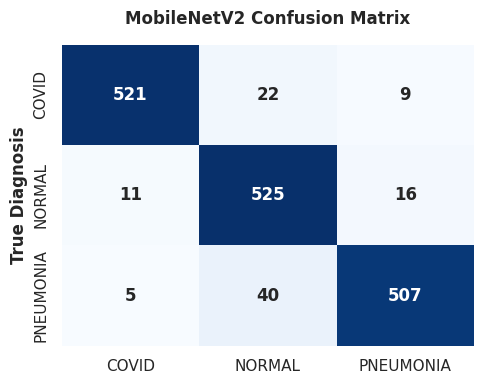

⚙️ BUILDING AND TRAINING: EfficientNetB0
Found 7716 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Found 1656 images belonging to 3 classes.
Epoch 1/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 123s 434ms/step - accuracy: 0.8481 - loss: 0.4367 - val_accuracy: 0.8992 - val_loss: 0.3068
Epoch 2/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 356ms/step - accuracy: 0.8990 - loss: 0.3016 - val_accuracy: 0.9263 - val_loss: 0.2447
Epoch 3/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 356ms/step - accuracy: 0.9134 - loss: 0.2643 - val_accuracy: 0.9318 - val_loss: 0.2172
Epoch 4/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 87s 357ms/step - accuracy: 0.9196 - loss: 0.2575 - val_accuracy: 0.9336 - val_loss: 0.2067
Epoch 5/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 355ms/step - accuracy: 0.9207 - loss: 0.2360 - val_accuracy: 0.9203 - val_loss: 0.2209
Epoch 6/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 355ms/step - accuracy: 0.9290 - loss: 0.2301 - val_accuracy: 0.9215 - val_loss: 0.2076
Epoch 7/10
242/242 ━━━━━━━━━━━━━━━━━━━━ 86s 35

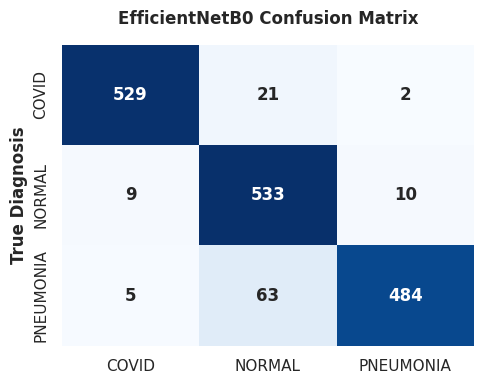


🎉 BENCHMARKING COMPLETE! Here is your final thesis table:

|    | Model Architecture   |   Test Accuracy (%) |   Test Loss |   Training Time (mins) |
|---:|:---------------------|--------------------:|------------:|-----------------------:|
|  0 | ResNet50             |               94.87 |      0.1474 |                  15.09 |
|  1 | MobileNetV2          |               93.78 |      0.1878 |                  12    |
|  2 | DenseNet121          |               93.72 |      0.2076 |                  15.05 |
|  3 | EfficientNetB0       |               93.36 |      0.1948 |                  15.01 |
|  4 | InceptionV3          |               90.82 |      0.2553 |                  14.05 |


In [17]:
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# 1. IMPORT ALL 5 MODELS AND THEIR SPECIFIC PREPROCESSORS
from tensorflow.keras.applications import ResNet50, DenseNet121, InceptionV3, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as prep_resnet
from tensorflow.keras.applications.densenet import preprocess_input as prep_densenet
from tensorflow.keras.applications.inception_v3 import preprocess_input as prep_inception
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as prep_mobilenet
from tensorflow.keras.applications.efficientnet import preprocess_input as prep_efficientnet

IMG_SIZE = 224
BATCH_SIZE = 32

# Dictionary containing the Model Class and its matching preprocessing function
models_to_test = {
    "ResNet50": (ResNet50, prep_resnet),
    "DenseNet121": (DenseNet121, prep_densenet),
    "InceptionV3": (InceptionV3, prep_inception),
    "MobileNetV2": (MobileNetV2, prep_mobilenet),
    "EfficientNetB0": (EfficientNetB0, prep_efficientnet)
}

results = []

print("🚀 Starting Sequential Benchmark of 5 Deep Learning Models...\n")

for model_name, (BaseModel, prep_func) in models_to_test.items():
    print(f"==================================================")
    print(f"⚙️ BUILDING AND TRAINING: {model_name}")
    print(f"==================================================")
    
    start_time = time.time()
    
    # 2. CREATE GENERATORS WITH THE CORRECT PREPROCESSING FOR THIS SPECIFIC MODEL
    train_gen = ImageDataGenerator(
        preprocessing_function=prep_func,
        rotation_range=10, width_shift_range=0.1, height_shift_range=0.1,
        zoom_range=0.1, horizontal_flip=True, fill_mode="nearest"
    ).flow_from_directory("split_dataset/train", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical")

    val_gen = ImageDataGenerator(preprocessing_function=prep_func)\
        .flow_from_directory("split_dataset/val", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

    test_gen = ImageDataGenerator(preprocessing_function=prep_func)\
        .flow_from_directory("split_dataset/test", target_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False)

    # 3. BUILD THE ARCHITECTURE
    base_model = BaseModel(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False # Transfer Learning Phase 1
    
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.2)(x) # Using your supervisor's recommended 0.2
    predictions = Dense(3, activation="softmax")(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    # 4. TRAIN (Shortened to 10 epochs max for benchmarking)
    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    
    model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early_stop], verbose=1)
    
    # 5. EVALUATE ON TEST SET
    print(f"\nEvaluating {model_name} on Test Set...")
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    
    end_time = time.time()
    training_time = round((end_time - start_time) / 60, 2) # in minutes
    
    print(f"✅ {model_name} Final Test Accuracy: {test_acc*100:.2f}%")
    
    # ---------------------------------------------------------
    # 6. DRAW CONFUSION MATRIX FOR THIS SPECIFIC MODEL
    # ---------------------------------------------------------
    print(f"📊 Generating Confusion Matrix for {model_name}...\n")
    test_gen.reset() # Crucial: Resets generator so predictions match true labels in order
    preds = model.predict(test_gen, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())
    
    cm = confusion_matrix(true_classes, pred_classes)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_labels, yticklabels=class_labels, 
                cbar=False, annot_kws={"size": 12, "weight": "bold"})
    plt.title(f'{model_name} Confusion Matrix', fontweight='bold', pad=15)
    plt.ylabel('True Diagnosis', fontweight='bold')
    plt.xlabel('', fontweight='bold')
    plt.tight_layout()
    plt.show() # <--- This prints the matrix immediately to your screen!
    # ---------------------------------------------------------
    
    # 7. SAVE RESULTS
    results.append({
        "Model Architecture": model_name,
        "Test Accuracy (%)": round(test_acc * 100, 2),
        "Test Loss": round(test_loss, 4),
        "Training Time (mins)": training_time
    })

# 8. GENERATE FINAL COMPARISON TABLE
print("\n🎉 BENCHMARKING COMPLETE! Here is your final thesis table:")
df_results = pd.DataFrame(results)
# Sort by highest accuracy
df_results = df_results.sort_values(by="Test Accuracy (%)", ascending=False).reset_index(drop=True)

print("\n" + df_results.to_markdown())

Retrieving live accuracies from memory...
✅ True VGG16 Accuracy retrieved: 96.92%


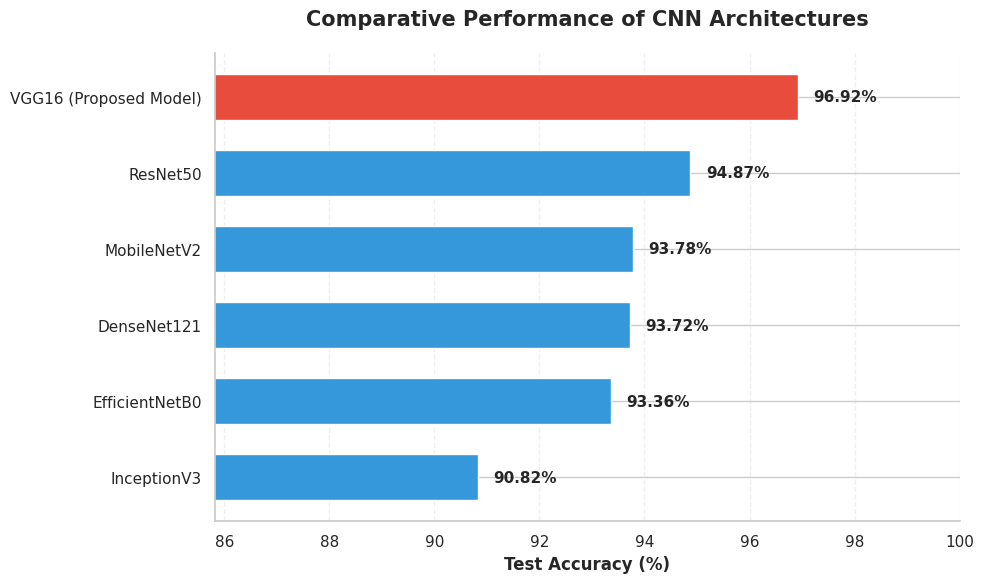

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

print("Retrieving live accuracies from memory...")

# 1. GET THE LIVE VGG16 ACCURACY
# (This pulls the unique variable you saved in your main VGG16 training cell)
try:
    vgg_acc_percentage = round(vgg16_test_acc * 100, 2)
    print(f"✅ True VGG16 Accuracy retrieved: {vgg_acc_percentage}%")
except NameError:
    print("⚠️ Warning: vgg16_test_acc not found in memory. Make sure you ran the VGG16 evaluation cell!")
    vgg_acc_percentage = 0.0

# 2. GET THE BENCHMARK RESULTS FROM YOUR LOOP
# We make a safe copy of the 'results' list generated by your benchmarking loop
try:
    graph_data = list(results)
except NameError:
    print("⚠️ Warning: The 'results' list from the benchmark loop was not found.")
    graph_data = []

# 3. SAFETY CLEANUP
# If you run this graph cell multiple times, this prevents VGG16 from duplicating
graph_data = [row for row in graph_data if "VGG16" not in row.get("Model Architecture", "")]

# 4. MERGE VGG16 WITH THE BENCHMARK MODELS
graph_data.append({
    "Model Architecture": "VGG16 (Proposed Model)",
    "Test Accuracy (%)": vgg_acc_percentage
})

# 5. AUTOMATICALLY SORT FROM HIGHEST TO LOWEST
df_results = pd.DataFrame(graph_data)
# Filter out any models that failed or haven't run yet (accuracy = 0.0)
df_results = df_results[df_results["Test Accuracy (%)"] > 0]
df_results = df_results.sort_values(by="Test Accuracy (%)", ascending=False).reset_index(drop=True)

# Extract the sorted names and numbers
models = df_results["Model Architecture"].tolist()
accuracies = df_results["Test Accuracy (%)"].tolist()

# 6. DYNAMIC COLOR SETUP 
# VGG16 gets warning-red to stand out, the rest get clinical blue
colors = ['#e74c3c' if 'Proposed' in m else '#3498db' for m in models]

# 7. PLOT THE CHART
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(models, accuracies, color=colors, height=0.6)

# FORMATTING FOR THESIS
ax.set_xlabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparative Performance of CNN Architectures', fontsize=15, fontweight='bold', pad=20)

# Dynamically set the X-axis limit based on the lowest accuracy in the list
if accuracies:
    min_acc = min(accuracies)
    # Starts the graph 5% below the worst model so the differences are highly visible
    ax.set_xlim(max(0, min_acc - 5), 100) 
    
ax.invert_yaxis() # Puts the highest accuracy at the top

# Add the exact percentage numbers to the end of every bar dynamically
for bar in bars:
    ax.text(bar.get_width() + 0.3, 
             bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.2f}%', 
             va='center', ha='left', fontsize=11, fontweight='bold')

# Clean up borders for a professional look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()